# CONFIG

In [16]:
import os
import pandas as pd
import numpy as np
import cv2

from maikol_utils.print_utils import print_separator
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
from src.config.config import Configuration

CONFIG = Configuration(
    crop_size=24,
    stride=2
)

# CODE

## Data

In [35]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

img_paths, n = list_dir_files(CONFIG.wider_path, recursive=True)
print(f"Found {n} files in {CONFIG.wider_path}")

Found 12880 files in data/others/WIDER_train/images


In [36]:
from src.model.haar_cascade_parser import HaarCascadeParser, load_cascade

# Load and parse the cascade
cascade_path = os.path.join(CONFIG.haar_cascades, 'haarcascade_frontalface_default.xml')
# cascade_path = os.path.join(CONFIG.haar_cascades, 'haarcascade_frontalcatface.xml')
cascade = load_cascade(cascade_path)

CONFIG.crop_size = max(cascade.height, cascade.width)

parser = HaarCascadeParser(cascade_path)
parser.print_summary(cascade)


Haar Cascade Summary
Type: opencv-cascade-classifier
Feature Type: HAAR
Size: 24x24
Total Stages: 25
Total Features: 2913
Max Weak Count: 211



## Construct class from parser

In [37]:
from src.model import CascadeClassifier
classifier = CascadeClassifier(CONFIG, cascade)

In [41]:
print(img_paths[0])
# img_path = "data/others/WIDER_train/images/0--Parade/0_Parade_marchingband_1_13.jpg"
# img_path = "data/others/WIDER_train/images/20--Family_Group/20_Family_Group_Family_Group_20_11.jpg"
img_path = "data/others/WIDER_train/images/9--Press_Conference/9_Press_Conference_Press_Conference_9_71.jpg"

from cv2 import imread
img = imread(img_path, cv2.IMREAD_GRAYSCALE)


data/others/WIDER_train/images/0--Parade/0_Parade_Parade_0_3.jpg


[ WARN:0@1258.713] global loadsave.cpp:278 findDecoder imread_('data/others/WIDER_train/images/9--Press_Conference/9_Press_Conference_Press_Conference_9_71.jpg'): can't open/read file: check file path/integrity


In [42]:
faces = classifier.predict(img_path=img_path)
len(faces)

Predicting faces...


[ WARN:0@1259.145] global loadsave.cpp:278 findDecoder imread_('data/others/WIDER_train/images/9--Press_Conference/9_Press_Conference_Press_Conference_9_71.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

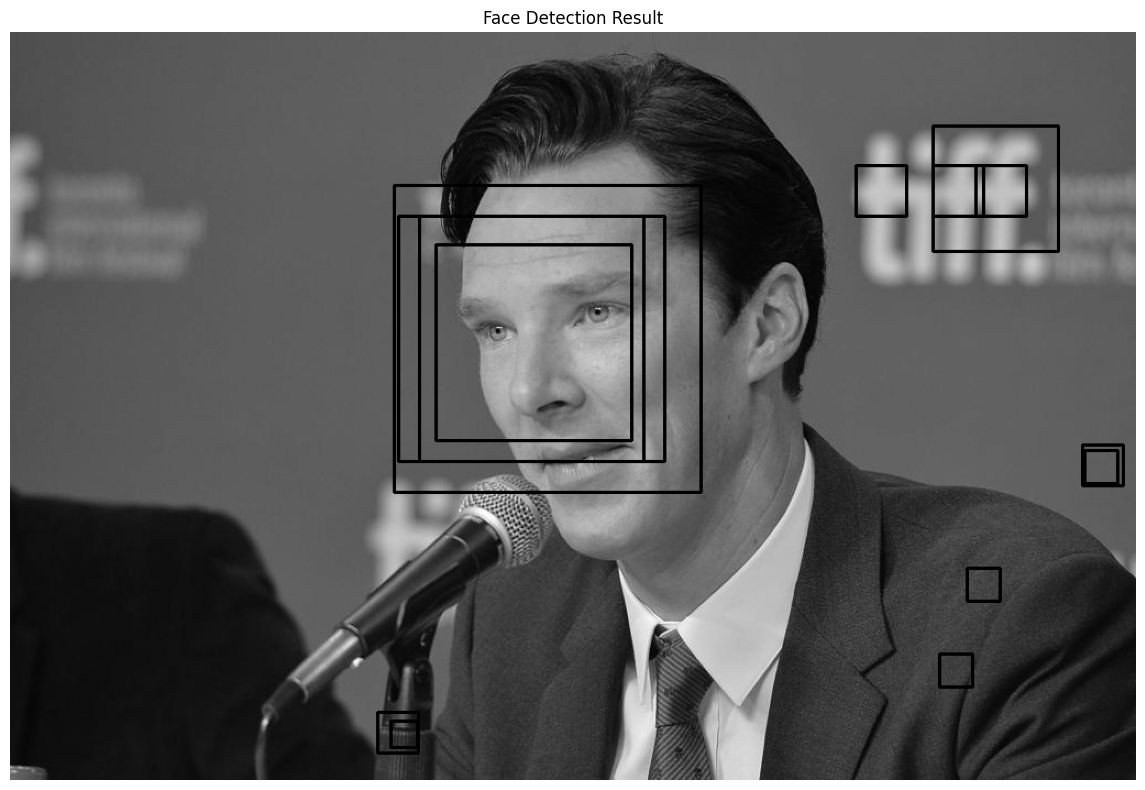

In [40]:
def draw_boxes(img, faces):
    for crop in faces:
        x, y, w, h = crop['x'], crop['y'], crop['w'], crop['h']
        # img, pt1, pt2, color (BGR), thickness
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return img

boxes = draw_boxes(img.copy(), faces)

plt.figure(figsize=(12, 8))
plt.imshow(boxes, cmap='gray')
plt.title('Face Detection Result')
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from src.data.crops import get_all_image_crops
crops = get_all_image_crops(
    CONFIG, 
    img_path=img_path
)
len(crops)

124963

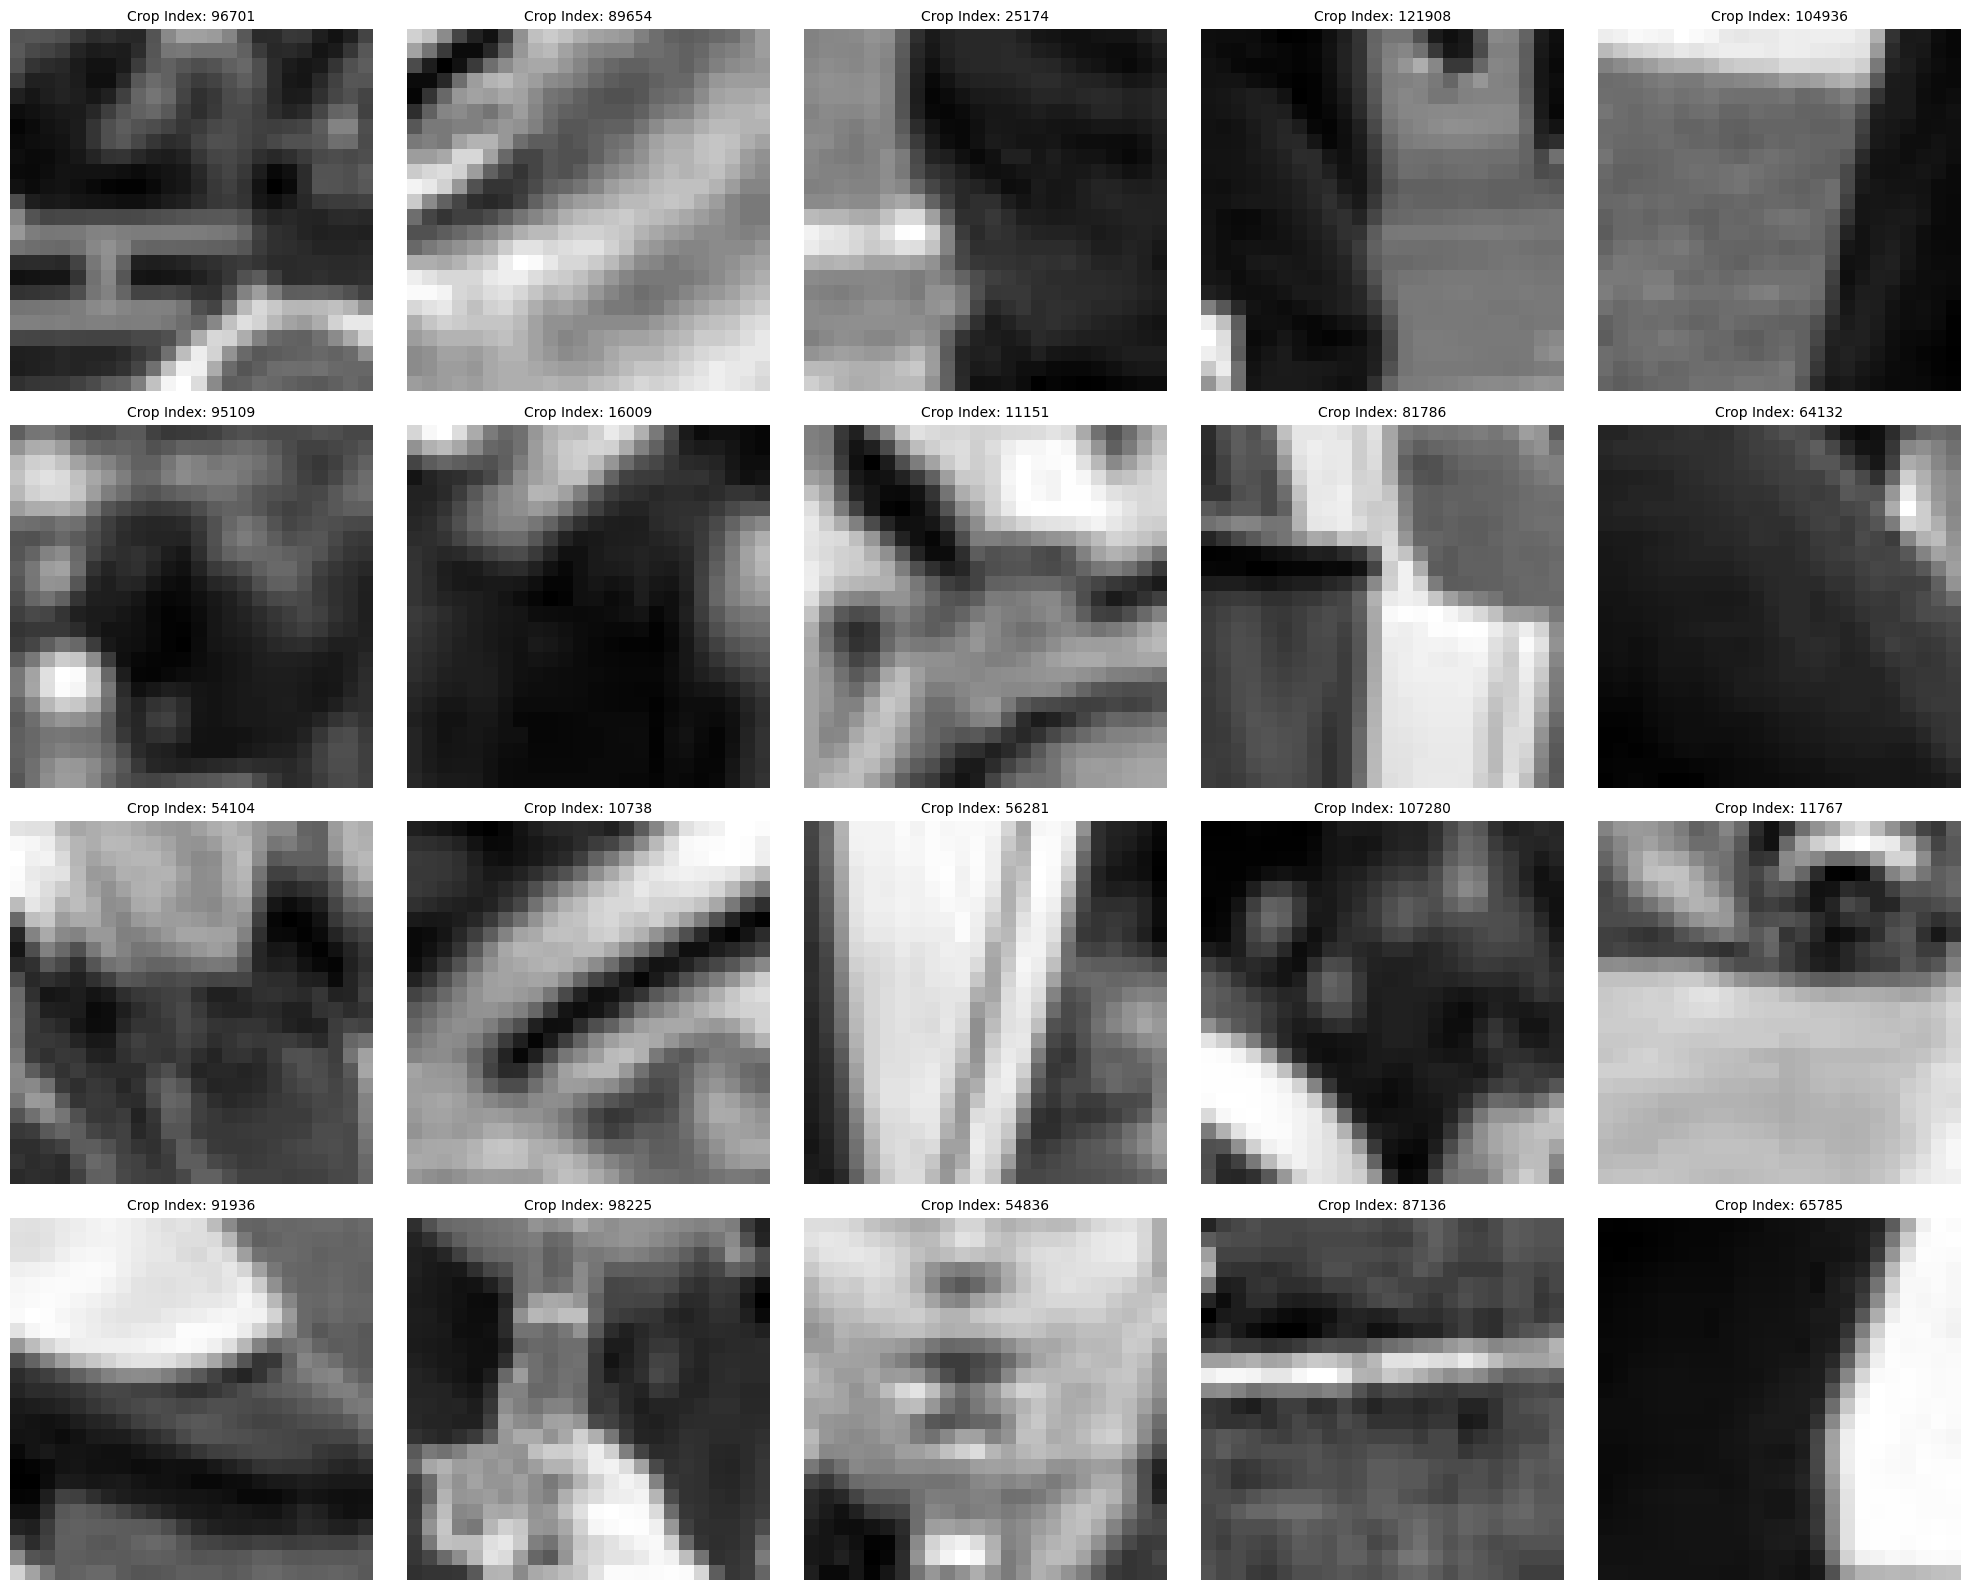

In [10]:
from PIL import Image
# Get random indices instead of random crops
sample_indices = rng.choice(len(crops), size=20, replace=False)
sample = [crops[i] for i in sample_indices]

def show_images(images, indices):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    for ax, img, crop_idx in zip(axes.flatten(), images, indices):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Crop Index: {crop_idx}', fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_images([i['img'] for i in sample], sample_indices)

In [38]:
import cv2

face_img = cv2.imread("data/ViolaJones/face_images/11.jpg", cv2.IMREAD_GRAYSCALE)

# scale to 24x24
face_img = cv2.resize(face_img, (24, 24))

In [39]:
face_img.shape

(24, 24)

In [40]:
# result = classifier._predict_crop(crops[79848]['img'])
# result = classifier._predict_crop(crops[11876]['img'])
result = classifier._predict_crop(face_img)

result

True

# Paralel predictions

In [23]:
from multiprocessing import Pool, cpu_count
from functools import partial
import time
import pandas as pd

# Wrapper function for multiprocessing (must be at module level in real code)
def predict_crop_wrapper(crop_data, classifier):
    """Wrapper to predict a single crop - required for multiprocessing"""
    idx, crop = crop_data
    result = classifier._predict_crop(crop['img'])
    return {
        'crop_idx': idx,
        'prediction': result,
        'crop_data': crop
    }

# METHOD 1: Using multiprocessing.Pool with process pool
print("=" * 60)
print("METHOD 1: multiprocessing.Pool")
print("=" * 60)

num_processes = int(cpu_count() * 2/3)
print(f"Using {num_processes} processes\n")

start_time = time.time()

# Create partial function with classifier bound
predict_func = partial(predict_crop_wrapper, classifier=classifier)

# Create pool and map function over crops with indices
with Pool(processes=num_processes) as pool:
    results = pool.map(predict_func, enumerate(crops))

elapsed_time = time.time() - start_time
print(f"Time taken (multiprocessing.Pool): {elapsed_time:.4f} seconds\n")

# Store results in DataFrame
df_results = pd.DataFrame(results)
print(f"Total predictions: {len(df_results)}")
print(f"Face detections: {df_results['prediction'].sum()}")
print(f"\nResults DataFrame (first 10 rows):")
print(df_results.head(10))

# Separate predictions and crops for easier access
predictions = df_results['prediction'].tolist()
print(f"\nPredictions stored: {len(predictions)}")


METHOD 1: multiprocessing.Pool
Using 16 processes



Time taken (multiprocessing.Pool): 35.8159 seconds

Total predictions: 1752351
Face detections: 0

Results DataFrame (first 10 rows):
   crop_idx  prediction                                          crop_data
0         0       False  {'x': 0, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
1         1       False  {'x': 1, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
2         2       False  {'x': 2, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
3         3       False  {'x': 3, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
4         4       False  {'x': 4, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
5         5       False  {'x': 5, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
6         6       False  {'x': 6, 'y': 0, 'w': 24, 'h': 24, 'img': [[20...
7         7       False  {'x': 7, 'y': 0, 'w': 24, 'h': 24, 'img': [[21...
8         8       False  {'x': 8, 'y': 0, 'w': 24, 'h': 24, 'img': [[21...
9         9       False  {'x': 9, 'y': 0, 'w': 24, 'h': 24, 'img': [[21...

Predictions stored: 1752351


In [ ]:
from concurrent.futures import ProcessPoolExecutor
import json
import pickle

# METHOD 2: Using concurrent.futures.ProcessPoolExecutor
print("\n" + "=" * 60)
print("METHOD 2: concurrent.futures.ProcessPoolExecutor")
print("=" * 60)

start_time = time.time()

predict_func = partial(predict_crop_wrapper, classifier=classifier)

with ProcessPoolExecutor(max_workers=num_processes) as executor:
    results_futures = list(executor.map(predict_func, enumerate(crops)))

elapsed_time = time.time() - start_time
print(f"Time taken (ProcessPoolExecutor): {elapsed_time:.4f} seconds\n")

df_results_2 = pd.DataFrame(results_futures)
print(f"Total predictions: {len(df_results_2)}")
print(f"Face detections: {df_results_2['prediction'].sum()}")

# Extract just predictions as numpy array for efficient storage
predictions_array = np.array(df_results_2['prediction'].tolist())
print(f"Predictions (numpy array) shape: {predictions_array.shape}")



METHOD 2: concurrent.futures.ProcessPoolExecutor


Process ForkProcess-132:
Process ForkProcess-134:
Process ForkProcess-130:
Process ForkProcess-121:
Process ForkProcess-128:
Process ForkProcess-129:
Process ForkProcess-131:
Process ForkProcess-135:


In [12]:
# STORAGE OPTIONS
print("\n" + "=" * 60)
print("STORAGE OPTIONS FOR RESULTS")
print("=" * 60)

# Create output directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# OPTION 1: Store as CSV (predictions and indices)
csv_data = df_results[['crop_idx', 'prediction']].copy()
csv_path = 'outputs/predictions.csv'
csv_data.to_csv(csv_path, index=False)
print(f"\n✓ CSV saved: {csv_path}")
print(f"  Size: {os.path.getsize(csv_path) / 1024:.2f} KB")

# OPTION 2: Store predictions as numpy binary (most efficient)
npy_path = 'outputs/predictions.npy'
np.save(npy_path, predictions_array)
print(f"✓ NumPy binary saved: {npy_path}")
print(f"  Size: {os.path.getsize(npy_path) / 1024:.2f} KB")

# OPTION 3: Store predictions as JSON
json_data = {
    'num_predictions': len(predictions_array),
    'num_faces': int(predictions_array.sum()),
    'predictions': predictions_array.tolist()
}
json_path = 'outputs/predictions.json'
with open(json_path, 'w') as f:
    json.dump(json_data, f)
print(f"✓ JSON saved: {json_path}")
print(f"  Size: {os.path.getsize(json_path) / 1024:.2f} KB")

# OPTION 4: Store full results (with crop data) as pickle
pickle_path = 'outputs/results_full.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(df_results, f)
print(f"✓ Pickle (full results) saved: {pickle_path}")
print(f"  Size: {os.path.getsize(pickle_path) / 1024:.2f} KB")

# OPTION 5: Store summary statistics
summary = {
    'total_crops': len(predictions_array),
    'faces_detected': int(predictions_array.sum()),
    'detection_rate': float(predictions_array.mean()),
    'processing_time': elapsed_time
}
summary_path = 'outputs/summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Summary saved: {summary_path}")

print(f"\nSummary Statistics:")
for key, value in summary.items():
    print(f"  {key}: {value}")



STORAGE OPTIONS FOR RESULTS

✓ CSV saved: outputs/predictions.csv
  Size: 106.36 KB
✓ NumPy binary saved: outputs/predictions.npy
  Size: 9.89 KB
✓ JSON saved: outputs/predictions.json
  Size: 68.42 KB
✓ Pickle (full results) saved: outputs/results_full.pkl
  Size: 6339.59 KB
✓ Summary saved: outputs/summary.json

Summary Statistics:
  total_crops: 10000
  faces_detected: 0
  detection_rate: 0.0
  processing_time: 52.95808815956116


In [13]:
# BENCHMARK: Sequential vs Parallel vs Storage size
print("\n" + "=" * 60)
print("BENCHMARK: Sequential vs Parallel")
print("=" * 60)

# Sequential benchmark (for comparison)
print("\nRunning sequential benchmark on 100 crops...")
start_time_seq = time.time()
sequential_results = []
for i in range(100):
    result = classifier._predict_crop(crops[i]['img'])
    sequential_results.append(result)
seq_time_100 = time.time() - start_time_seq

print(f"Sequential (100 crops): {seq_time_100:.4f} seconds")
print(f"Estimated time for 10,000: {seq_time_100 * 100:.2f} seconds")
print(f"Parallel (10,000 crops): {elapsed_time:.4f} seconds")
print(f"Speedup: {(seq_time_100 * 100) / elapsed_time:.2f}x")

# LOADING STORED RESULTS
print("\n" + "=" * 60)
print("LOADING STORED RESULTS")
print("=" * 60)

# Load from CSV
df_loaded_csv = pd.read_csv('outputs/predictions.csv')
print(f"\n✓ Loaded from CSV: {len(df_loaded_csv)} predictions")

# Load from NumPy
predictions_loaded = np.load('outputs/predictions.npy')
print(f"✓ Loaded from NumPy: {len(predictions_loaded)} predictions")

# Load from JSON
with open('outputs/predictions.json', 'r') as f:
    json_loaded = json.load(f)
print(f"✓ Loaded from JSON: {json_loaded['num_predictions']} predictions")

# Load from Pickle
with open('outputs/results_full.pkl', 'rb') as f:
    df_loaded_pickle = pickle.load(f)
print(f"✓ Loaded from Pickle: {len(df_loaded_pickle)} predictions")

# Verify all methods loaded same data
print("\n✓ Data integrity verified:" )
print(f"  All methods match: {(df_loaded_csv['prediction'].values == predictions_loaded).all()}")



BENCHMARK: Sequential vs Parallel

Running sequential benchmark on 100 crops...
Sequential (100 crops): 0.0233 seconds
Estimated time for 10,000: 2.33 seconds
Parallel (10,000 crops): 52.9581 seconds
Speedup: 0.04x

LOADING STORED RESULTS

✓ Loaded from CSV: 10000 predictions
✓ Loaded from NumPy: 10000 predictions
✓ Loaded from JSON: 10000 predictions
✓ Loaded from Pickle: 10000 predictions

✓ Data integrity verified:
  All methods match: True


# Print the parser

In [14]:
parser.print_stages_summary(cascade)


Stages Summary

Stage 0:
  Threshold: -5.0425500870
  Weak Classifiers: 9
  Max Count: 9
    WeakClassifier(0): Feature 0, threshold=-0.031512, left=2.087538, right=-2.217210
    WeakClassifier(1): Feature 1, threshold=0.012396, left=-1.863394, right=1.327205
    WeakClassifier(2): Feature 2, threshold=0.021928, left=-1.510525, right=1.062573
    WeakClassifier(3): Feature 3, threshold=0.005753, left=-0.874639, right=1.176034
    WeakClassifier(4): Feature 4, threshold=0.015014, left=-0.779457, right=1.260842
    ... and 4 more

Stage 1:
  Threshold: -4.9842400551
  Weak Classifiers: 16
  Max Count: 16
    WeakClassifier(0): Feature 9, threshold=-0.021110, left=1.243565, right=-1.571301
    WeakClassifier(1): Feature 10, threshold=0.020356, left=-1.620478, right=1.181776
    WeakClassifier(2): Feature 11, threshold=0.021309, left=-1.941593, right=0.700691
    WeakClassifier(3): Feature 12, threshold=0.091660, left=-0.556701, right=1.728442
    WeakClassifier(4): Feature 13, threshold=

In [15]:
parser.print_features_summary(cascade)


Features Summary

Feature 0:
  Rect(x=6, y=4, w=12, h=9, weight=-1.0)
  Rect(x=6, y=7, w=12, h=3, weight=3.0)

Feature 1:
  Rect(x=6, y=4, w=12, h=7, weight=-1.0)
  Rect(x=10, y=4, w=4, h=7, weight=3.0)

Feature 2:
  Rect(x=3, y=9, w=18, h=9, weight=-1.0)
  Rect(x=3, y=12, w=18, h=3, weight=3.0)

Feature 3:
  Rect(x=8, y=18, w=9, h=6, weight=-1.0)
  Rect(x=8, y=20, w=9, h=2, weight=3.0)

Feature 4:
  Rect(x=3, y=5, w=4, h=19, weight=-1.0)
  Rect(x=5, y=5, w=2, h=19, weight=2.0)

Feature 5:
  Rect(x=6, y=5, w=12, h=16, weight=-1.0)
  Rect(x=6, y=13, w=12, h=8, weight=2.0)

Feature 6:
  Rect(x=5, y=8, w=12, h=6, weight=-1.0)
  Rect(x=5, y=11, w=12, h=3, weight=2.0)

Feature 7:
  Rect(x=11, y=14, w=4, h=10, weight=-1.0)
  Rect(x=11, y=19, w=4, h=5, weight=2.0)

Feature 8:
  Rect(x=4, y=0, w=7, h=6, weight=-1.0)
  Rect(x=4, y=3, w=7, h=3, weight=2.0)

Feature 9:
  Rect(x=6, y=6, w=12, h=6, weight=-1.0)
  Rect(x=6, y=8, w=12, h=2, weight=3.0)

... and 2903 more features


## Access Cascade Data Programmatically

In [16]:
# Access specific stage
stage_idx = 0
stage = cascade.stages[stage_idx]

print(f"Stage {stage_idx}:")
print(f"  Threshold: {stage.threshold}")
print(f"  Number of weak classifiers: {len(stage.weak_classifiers)}")
print()

# Access weak classifiers in that stage
for clf in stage.weak_classifiers[:3]:
    print(f"Weak Classifier {clf.classifier_id}:")
    print(f"  Feature ID: {clf.feature_id}")
    print(f"  Classifier Threshold: {clf.threshold:.10f}")
    print(f"  Left Value:  {clf.left_value:.10f}")
    print(f"  Right Value: {clf.right_value:.10f}")
    
    # Access the actual feature
    if clf.feature is not None:
        print(f"  Feature has {len(clf.feature.rectangles)} rectangles:")
        for rect in clf.feature.rectangles:
            print(f"    {rect}")
    print()

Stage 0:
  Threshold: -5.042550086975098
  Number of weak classifiers: 9

Weak Classifier 0:
  Feature ID: 0
  Classifier Threshold: -0.0315119997
  Left Value:  2.0875380039
  Right Value: -2.2172100544
  Feature has 2 rectangles:
    Rect(x=6, y=4, w=12, h=9, weight=-1.0)
    Rect(x=6, y=7, w=12, h=3, weight=3.0)

Weak Classifier 1:
  Feature ID: 1
  Classifier Threshold: 0.0123960003
  Left Value:  -1.8633940220
  Right Value: 1.3272049427
  Feature has 2 rectangles:
    Rect(x=6, y=4, w=12, h=7, weight=-1.0)
    Rect(x=10, y=4, w=4, h=7, weight=3.0)

Weak Classifier 2:
  Feature ID: 2
  Classifier Threshold: 0.0219279993
  Left Value:  -1.5105249882
  Right Value: 1.0625729561
  Feature has 2 rectangles:
    Rect(x=3, y=9, w=18, h=9, weight=-1.0)
    Rect(x=3, y=12, w=18, h=3, weight=3.0)



In [17]:
# Create DataFrame with all weak classifiers from all stages
classifiers_data = []
for stage in cascade.stages:
    for clf in stage.weak_classifiers:
        classifiers_data.append({
            'stage': stage.stage_id,
            'stage_threshold': stage.threshold,
            'classifier_id': clf.classifier_id,
            'feature_id': clf.feature_id,
            'classifier_threshold': clf.threshold,
            'left_value': clf.left_value,
            'right_value': clf.right_value,
            'num_rects': len(clf.feature.rectangles) if clf.feature else 0
        })

df_classifiers = pd.DataFrame(classifiers_data)
print(f"Total weak classifiers: {len(df_classifiers)}")
print(f"\nFirst 10 classifiers:")
print(df_classifiers.head(10))

Total weak classifiers: 2913

First 10 classifiers:
   stage  stage_threshold  classifier_id  feature_id  classifier_threshold  \
0      0         -5.04255              0           0             -0.031512   
1      0         -5.04255              1           1              0.012396   
2      0         -5.04255              2           2              0.021928   
3      0         -5.04255              3           3              0.005753   
4      0         -5.04255              4           4              0.015014   
5      0         -5.04255              5           5              0.099371   
6      0         -5.04255              6           6              0.002734   
7      0         -5.04255              7           7             -0.018859   
8      0         -5.04255              8           8              0.005974   
9      1         -4.98424              0           9             -0.021110   

   left_value  right_value  num_rects  
0    2.087538    -2.217210          2  
1   -1.86

In [18]:
# Example: Extract all rectangles from all features
features_data = []
for feat_id, feature in cascade.features.items():
    for rect_idx, rect in enumerate(feature.rectangles):
        features_data.append({
            'feature_id': feat_id,
            'rect_index': rect_idx,
            'x': rect.x,
            'y': rect.y,
            'width': rect.width,
            'height': rect.height,
            'weight': rect.weight
        })

df_features = pd.DataFrame(features_data)
print(f"Total rectangles across all features: {len(df_features)}")
print(f"\nFirst 15 rectangles:")
print(df_features.head(15))

Total rectangles across all features: 6383

First 15 rectangles:
    feature_id  rect_index   x   y  width  height  weight
0            0           0   6   4     12       9    -1.0
1            0           1   6   7     12       3     3.0
2            1           0   6   4     12       7    -1.0
3            1           1  10   4      4       7     3.0
4            2           0   3   9     18       9    -1.0
5            2           1   3  12     18       3     3.0
6            3           0   8  18      9       6    -1.0
7            3           1   8  20      9       2     3.0
8            4           0   3   5      4      19    -1.0
9            4           1   5   5      2      19     2.0
10           5           0   6   5     12      16    -1.0
11           5           1   6  13     12       8     2.0
12           6           0   5   8     12       6    -1.0
13           6           1   5  11     12       3     2.0
14           7           0  11  14      4      10    -1.0
